In [31]:
# ================================
# NOTEBOOK SETUP
# ================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import json

from scipy.stats import mannwhitneyu

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


# ================================
# PROJECT PATH
# ================================

ROOT = Path.cwd().parent

DATA_PATH = (
    ROOT /
    "data" /
    "processed" /
    "master_modeling.csv"
)

MODEL_DIR = (
    ROOT /
    "logistics-ai" /
    "models"
)


# ================================
# LOAD DATA
# ================================

df = pd.read_csv(DATA_PATH)

df["departure_date"] = pd.to_datetime(
    df["departure_date"]
)


# ================================
# LOAD MODEL CONFIG
# ================================

with open(
    MODEL_DIR / "feature_columns.json",
    "r"
) as f:

    feature_config = json.load(f)


feature_columns = (
    feature_config["feature_names"]
)

numeric_features_model = (
    feature_config["numeric_features"]
)

categorical_features_model = (
    feature_config["categorical_features"]
)

target_column = feature_config["target"]


# ================================
# LOAD MODEL
# ================================

model = joblib.load(
    MODEL_DIR / "delay_xgboost.pkl"
)

preprocessor = joblib.load(
    MODEL_DIR / "preprocessor.pkl"
)


# ================================
# VERIFY
# ================================

print("========== NOTEBOOK READY ==========")
print("Dataset:", df.shape)
print("Model features:", len(feature_columns))
print("Numerical features:", len(numeric_features_model))
print("Categorical features:", len(categorical_features_model))
print("Target:", target_column)
print("Model:", type(model).__name__)
print("Preprocessor:", type(preprocessor).__name__)

========== NOTEBOOK READY ==========
Dataset: (12308, 38)
Model features: 33
Numerical features: 30
Categorical features: 3
Target: delay
Model: XGBClassifier
Preprocessor: ColumnTransformer


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy.stats import mannwhitneyu

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [33]:
ROOT = Path.cwd().parent

print("Current notebook folder:", Path.cwd())
print("Project root:", ROOT)

Current notebook folder: c:\Users\shriv\logistics\notebooks
Project root: c:\Users\shriv\logistics


In [34]:
processed_dir = ROOT / "data" / "processed"

print("Processed folder exists:", processed_dir.exists())

for file in processed_dir.iterdir():
    print(file.name)

Processed folder exists: True
imputation_medians.json
master_modeling.csv


In [35]:
df = pd.read_csv(
    ROOT / "data" / "processed" / "master_modeling.csv"
)

print(f"Loaded {len(df):,} records")
print(f"Shape: {df.shape}")

Loaded 12,308 records
Shape: (12308, 38)


In [36]:
print(df.columns.tolist())

['truck_id', 'route_id', 'departure_date', 'estimated_arrival', 'hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'is_peak_hour', 'truck_age', 'load_capacity_pounds', 'mileage_mpg', 'fuel_type', 'driver_age', 'experience', 'driving_style', 'driver_ratings', 'average_speed_mph', 'distance', 'average_hours', 'weather_temp', 'weather_wind_speed', 'weather_precip', 'weather_humidity', 'weather_visibility', 'weather_chanceofrain', 'weather_chanceoffog', 'weather_chanceofsnow', 'weather_chanceofthunder', 'traffic_vehicles', 'traffic_accident', 'truck_age_category', 'truck_trip_count_hist', 'truck_delay_rate_hist', 'route_trip_count_hist', 'route_delay_rate_hist', 'delay']


In [37]:
df.head()

,truck_id,route_id,departure_date,estimated_arrival,hour,day_of_week,day_of_month,month,is_weekend,is_peak_hour,truck_age,load_capacity_pounds,mileage_mpg,fuel_type,driver_age,experience,driving_style,driver_ratings,average_speed_mph,distance,average_hours,weather_temp,weather_wind_speed,weather_precip,weather_humidity,weather_visibility,weather_chanceofrain,weather_chanceoffog,weather_chanceofsnow,weather_chanceofthunder,traffic_vehicles,traffic_accident,truck_age_category,truck_trip_count_hist,truck_delay_rate_hist,route_trip_count_hist,route_delay_rate_hist,delay
0,30822651,R-003c7a81,2019-01-01 07:00:00,2019-01-01 11:45:36.000000000,7,1,1,1,0,1,9.0,4000.0,18.0,gas,55.0,24.0,conservative,9,54.19,237.96,4.76,61.5,7.50,0.0,76.25,6.00,0.0,0.0,0.0,0.0,2812.0,0,mid,0,0.348879,0,0.348879,0
1,35475873,R-cd3d1fa1,2019-01-01 07:00:00,2019-01-01 16:30:36.000000000,7,1,1,1,0,1,9.0,6000.0,19.0,gas,43.0,10.0,proactive,8,62.00,475.27,9.51,40.0,6.00,0.0,86.75,5.25,0.0,0.0,0.0,0.0,2284.0,0,mid,0,0.348879,0,0.348879,0
2,11486762,R-1a63935d,2019-01-01 07:00:00,2019-01-06 05:49:12.000000000,7,1,1,1,0,1,8.0,15000.0,17.0,gas,46.0,0.0,proactive,2,58.34,5940.98,118.82,59.5,5.50,0.0,64.00,6.00,0.0,0.0,0.0,0.0,2394.0,0,mid,0,0.348879,0,0.348879,0
3,88231513,R-847ea29d,2019-01-01 07:00:00,2019-01-01 12:33:36.000000000,7,1,1,1,0,1,6.0,3000.0,17.0,gas,48.0,12.0,conservative,6,39.22,277.85,5.56,51.0,3.25,0.0,81.75,6.00,0.0,0.0,0.0,0.0,2202.0,0,mid,0,0.348879,0,0.348879,0
4,93814071,R-cd48eb77,2019-01-01 07:00:00,2019-01-08 10:06:00.000000000,7,1,1,1,0,1,8.0,6000.0,22.0,diesel,53.0,22.0,unknown,4,63.89,8555.22,171.10,80.0,8.25,0.0,58.25,6.00,0.0,0.0,0.0,0.0,1921.0,0,mid,0,0.348879,0,0.348879,1


In [38]:
df["departure_date"] = pd.to_datetime(df["departure_date"])

print(df["departure_date"].min())
print(df["departure_date"].max())

2019-01-01 07:00:00
2019-02-12 07:00:00


In [39]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing Values")
display(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicates")
print(df.duplicated().sum())

Rows: 12308
Columns: 38

Missing Values


truck_id                   0
route_id                   0
departure_date             0
estimated_arrival          0
hour                       0
day_of_week                0
day_of_month               0
month                      0
is_weekend                 0
is_peak_hour               0
truck_age                  0
load_capacity_pounds       0
mileage_mpg                0
fuel_type                  0
driver_age                 0
experience                 0
driving_style              0
driver_ratings             0
average_speed_mph          0
distance                   0
average_hours              0
weather_temp               0
weather_wind_speed         0
weather_precip             0
weather_humidity           0
weather_visibility         0
weather_chanceofrain       0
weather_chanceoffog        0
weather_chanceofsnow       0
weather_chanceofthunder    0
traffic_vehicles           0
traffic_accident           0
truck_age_category         0
truck_trip_count_hist      0
truck_delay_ra


Duplicates
0


In [40]:
print(df["delay"].value_counts())

print("\nPercentage")

display(
    df["delay"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

delay
0    8014
1    4294
Name: count, dtype: int64

Percentage


delay
0    65.11
1    34.89
Name: proportion, dtype: float64

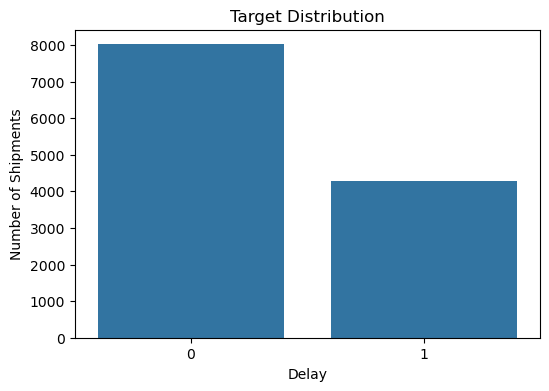

In [41]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="delay"
)

plt.title("Target Distribution")
plt.xlabel("Delay")
plt.ylabel("Number of Shipments")

plt.show()

In [42]:
numeric_features = [
    # Time
    "hour",
    "day_of_week",
    "day_of_month",
    "month",
    "is_weekend",
    "is_peak_hour",

    # Truck
    "truck_age",
    "load_capacity_pounds",
    "mileage_mpg",

    # Driver
    "driver_age",
    "experience",
    "driver_ratings",
    "average_speed_mph",

    # Route
    "distance",
    "average_hours",

    # Weather
    "weather_temp",
    "weather_wind_speed",
    "weather_precip",
    "weather_humidity",
    "weather_visibility",
    "weather_chanceofrain",
    "weather_chanceoffog",
    "weather_chanceofsnow",
    "weather_chanceofthunder",

    # Traffic
    "traffic_vehicles",
    "traffic_accident",

    # Historical
    "truck_trip_count_hist",
    "truck_delay_rate_hist",
    "route_trip_count_hist",
    "route_delay_rate_hist"
]

categorical_features = [
    "fuel_type",
    "driving_style",
    "truck_age_category"
]

# Keep only columns that actually exist in the dataset
numeric_features = [
    col for col in numeric_features
    if col in df.columns
]

categorical_features = [
    col for col in categorical_features
    if col in df.columns
]

print("Numerical features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

Numerical features: 30
['hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'is_peak_hour', 'truck_age', 'load_capacity_pounds', 'mileage_mpg', 'driver_age', 'experience', 'driver_ratings', 'average_speed_mph', 'distance', 'average_hours', 'weather_temp', 'weather_wind_speed', 'weather_precip', 'weather_humidity', 'weather_visibility', 'weather_chanceofrain', 'weather_chanceoffog', 'weather_chanceofsnow', 'weather_chanceofthunder', 'traffic_vehicles', 'traffic_accident', 'truck_trip_count_hist', 'truck_delay_rate_hist', 'route_trip_count_hist', 'route_delay_rate_hist']

Categorical features: 3
['fuel_type', 'driving_style', 'truck_age_category']


In [43]:
print("ACTUAL DATASET COLUMNS")
print("=" * 60)

for i, col in enumerate(df.columns, 1):
    print(f"{i:2}. {col}")

ACTUAL DATASET COLUMNS
 1. truck_id
 2. route_id
 3. departure_date
 4. estimated_arrival
 5. hour
 6. day_of_week
 7. day_of_month
 8. month
 9. is_weekend
10. is_peak_hour
11. truck_age
12. load_capacity_pounds
13. mileage_mpg
14. fuel_type
15. driver_age
16. experience
17. driving_style
18. driver_ratings
19. average_speed_mph
20. distance
21. average_hours
22. weather_temp
23. weather_wind_speed
24. weather_precip
25. weather_humidity
26. weather_visibility
27. weather_chanceofrain
28. weather_chanceoffog
29. weather_chanceofsnow
30. weather_chanceofthunder
31. traffic_vehicles
32. traffic_accident
33. truck_age_category
34. truck_trip_count_hist
35. truck_delay_rate_hist
36. route_trip_count_hist
37. route_delay_rate_hist
38. delay


In [44]:
missing = [
    col for col in numeric_features
    if col not in df.columns
]

print("Missing numerical columns:")
print(missing)

missing_cat = [
    col for col in categorical_features
    if col not in df.columns
]

print("Missing categorical columns:")
print(missing_cat)

Missing numerical columns:
[]
Missing categorical columns:
[]


In [45]:
comparison = (
    df.groupby("delay")[numeric_features]
    .median()
    .T
)

comparison.columns = [
    "On_Time",
    "Delayed"
]

comparison["Difference"] = (
    comparison["Delayed"]
    - comparison["On_Time"]
)

comparison = comparison.sort_values(
    "Difference",
    key=np.abs,
    ascending=False
)

display(comparison)

,On_Time,Delayed,Difference
distance,625.540000,1014.010000,388.470000
traffic_vehicles,2172.000000,2163.000000,-9.000000
average_hours,12.510000,20.285000,7.775000
day_of_month,10.000000,13.000000,3.000000
weather_humidity,71.750000,72.750000,1.000000
average_speed_mph,57.230000,57.360000,0.130000
weather_wind_speed,7.750000,7.625000,-0.125000
truck_delay_rate_hist,0.285714,0.333333,0.047619
route_delay_rate_hist,0.333333,0.348879,0.015545
is_weekend,0.000000,0.000000,0.000000


In [46]:
corr = (
    df[numeric_features + ["delay"]]
    .corr()
)

delay_corr = (
    corr["delay"]
    .drop("delay")
    .sort_values()
)

display(delay_corr.to_frame("Correlation"))

,Correlation
weather_wind_speed,-0.022759
weather_temp,-0.018147
weather_visibility,-0.017374
truck_trip_count_hist,-0.013915
traffic_vehicles,-0.010546
route_trip_count_hist,-0.009463
traffic_accident,-0.007521
average_speed_mph,-0.007319
driver_ratings,-0.005785
load_capacity_pounds,-0.005631


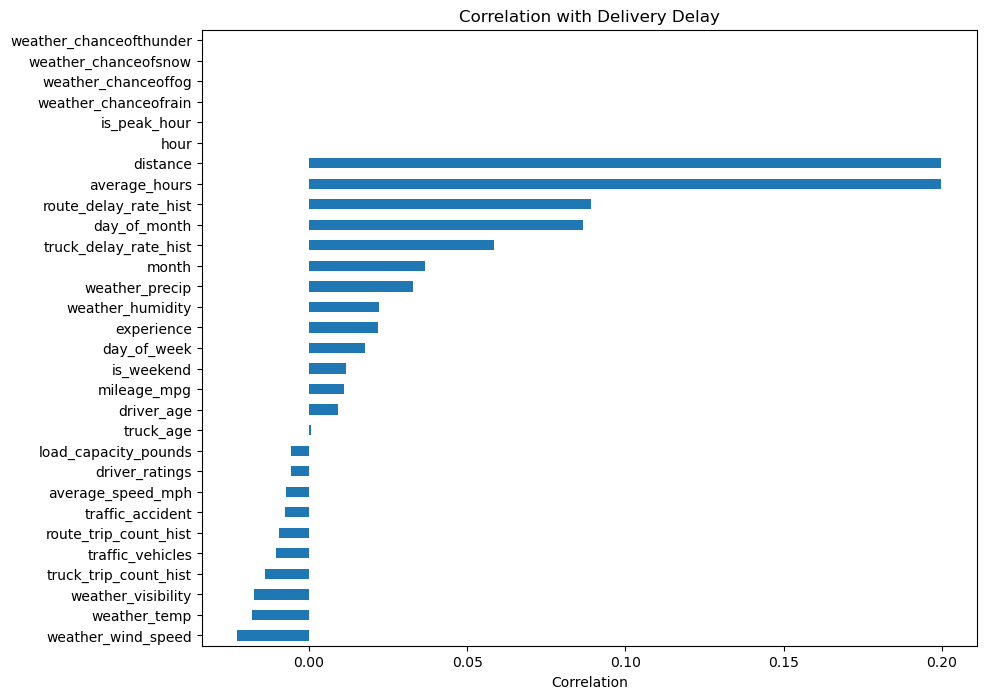

In [47]:
plt.figure(figsize=(10,8))

delay_corr.plot(
    kind="barh"
)

plt.title("Correlation with Delivery Delay")
plt.xlabel("Correlation")

plt.show()

In [48]:
results = []

for feature in numeric_features:

    a = df.loc[
        df["delay"] == 0,
        feature
    ].dropna()

    b = df.loc[
        df["delay"] == 1,
        feature
    ].dropna()

    stat, p = mannwhitneyu(
        a,
        b,
        alternative="two-sided"
    )

    results.append({
        "Feature": feature,
        "P_Value": p
    })

stats_df = pd.DataFrame(results)

stats_df["Significant"] = (
    stats_df["P_Value"] < 0.05
)

stats_df = stats_df.sort_values("P_Value")

display(stats_df)

,Feature,P_Value,Significant
14,average_hours,1.445266e-269,True
13,distance,1.510925e-269,True
2,day_of_month,1.165654e-26,True
29,route_delay_rate_hist,1.625128e-18,True
27,truck_delay_rate_hist,6.367315e-08,True
3,month,4.409725e-05,True
17,weather_precip,1.352677e-03,True
19,weather_visibility,4.461833e-03,True
16,weather_wind_speed,9.830564e-03,True
18,weather_humidity,1.145398e-02,True


In [49]:
def cliffs_delta(x, y):

    x = np.asarray(x)
    y = np.asarray(y)

    greater = 0
    less = 0

    for value in x:
        greater += np.sum(value > y)
        less += np.sum(value < y)

    return (
        greater - less
    ) / (len(x) * len(y))

In [50]:
effect_results = []

for feature in numeric_features:

    ontime = df.loc[
        df.delay == 0,
        feature
    ].dropna()

    delayed = df.loc[
        df.delay == 1,
        feature
    ].dropna()

    delta = cliffs_delta(
        ontime,
        delayed
    )

    effect_results.append({
        "Feature": feature,
        "Cliffs_Delta": delta,
        "Absolute_Effect": abs(delta)
    })

effect_df = pd.DataFrame(effect_results)

effect_df = effect_df.sort_values(
    "Absolute_Effect",
    ascending=False
)

display(effect_df)

,Feature,Cliffs_Delta,Absolute_Effect
14,average_hours,-0.383030,0.383030
13,distance,-0.383016,0.383016
2,day_of_month,-0.116486,0.116486
29,route_delay_rate_hist,-0.093971,0.093971
27,truck_delay_rate_hist,-0.058704,0.058704
3,month,-0.033682,0.033682
16,weather_wind_speed,0.028181,0.028181
18,weather_humidity,-0.027609,0.027609
19,weather_visibility,0.027461,0.027461
10,experience,-0.023629,0.023629


In [51]:
impact_df = pd.DataFrame({
    "Feature": delay_corr.index,
    "Correlation": delay_corr.values
})

impact_df = impact_df.merge(
    stats_df,
    on="Feature"
)

impact_df = impact_df.merge(
    effect_df,
    on="Feature"
)

impact_df = impact_df.sort_values(
    "Absolute_Effect",
    ascending=False
)

display(impact_df)

,Feature,Correlation,P_Value,Significant,Cliffs_Delta,Absolute_Effect
22,average_hours,0.199899,1.445266e-269,True,-0.383030,0.383030
23,distance,0.199900,1.510925e-269,True,-0.383016,0.383016
20,day_of_month,0.086596,1.165654e-26,True,-0.116486,0.116486
21,route_delay_rate_hist,0.088989,1.625128e-18,True,-0.093971,0.093971
19,truck_delay_rate_hist,0.058523,6.367315e-08,True,-0.058704,0.058704
18,month,0.036822,4.409725e-05,True,-0.033682,0.033682
0,weather_wind_speed,-0.022759,9.830564e-03,True,0.028181,0.028181
16,weather_humidity,0.022025,1.145398e-02,True,-0.027609,0.027609
2,weather_visibility,-0.017374,4.461833e-03,True,0.027461,0.027461
15,experience,0.021829,3.029180e-02,True,-0.023629,0.023629


In [52]:
df["distance_group"] = pd.qcut(
    df["distance"],
    5,
    labels=[
        "Very Short",
        "Short",
        "Medium",
        "Long",
        "Very Long"
    ]
)

distance_result = (
    df.groupby(
        "distance_group",
        observed=True
    )["delay"]
    .agg(
        Delay_Rate="mean",
        Shipments="count"
    )
)

distance_result["Delay_Rate"] *= 100

display(distance_result)

,Delay_Rate,Shipments
distance_group,,
Very Short,18.329278,2466
Short,19.065041,2460
Medium,27.335220,2473
Long,56.723716,2454
Very Long,53.156823,2455


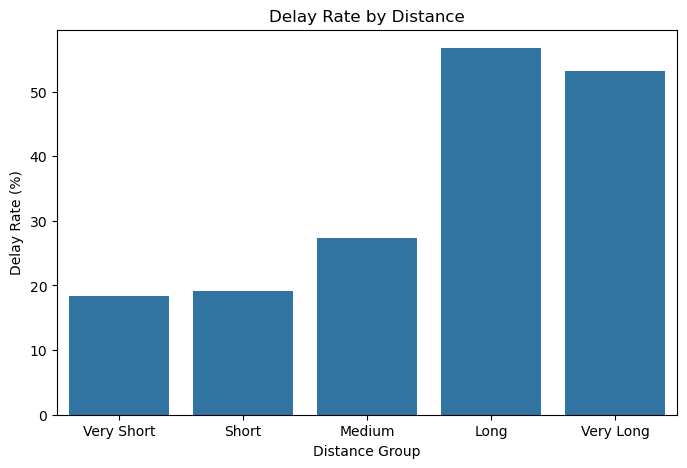

In [53]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=distance_result.reset_index(),
    x="distance_group",
    y="Delay_Rate"
)

plt.title("Delay Rate by Distance")
plt.ylabel("Delay Rate (%)")
plt.xlabel("Distance Group")

plt.show()

In [54]:
df["traffic_group"] = pd.qcut(
    df["traffic_vehicles"],
    5,
    duplicates="drop"
)

traffic_result = (
    df.groupby(
        "traffic_group",
        observed=True
    )["delay"]
    .agg(
        Delay_Rate="mean",
        Shipments="count"
    )
)

traffic_result["Delay_Rate"] *= 100

display(traffic_result)

,Delay_Rate,Shipments
traffic_group,,
"(-0.001, 1717.0]",35.511364,2464
"(1717.0, 2046.0]",35.207921,2525
"(2046.0, 2259.4]",37.395659,2396
"(2259.4, 2459.4]",32.344575,2461
"(2459.4, 3341.0]",34.037368,2462


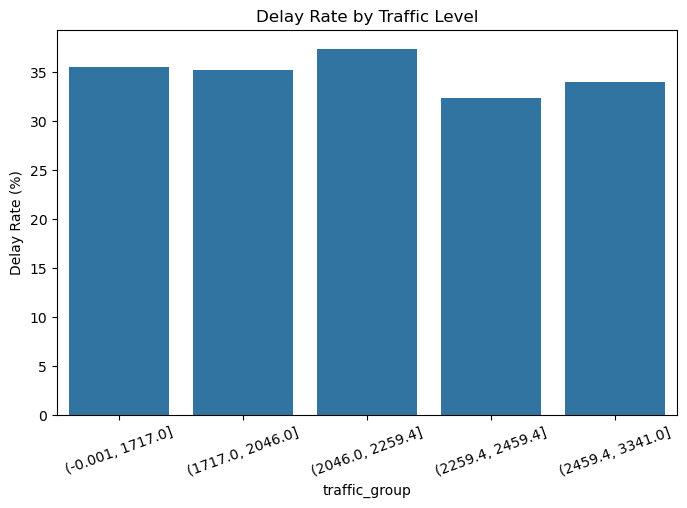

In [55]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=traffic_result.reset_index(),
    x="traffic_group",
    y="Delay_Rate"
)

plt.xticks(rotation=20)

plt.title("Delay Rate by Traffic Level")
plt.ylabel("Delay Rate (%)")

plt.show()

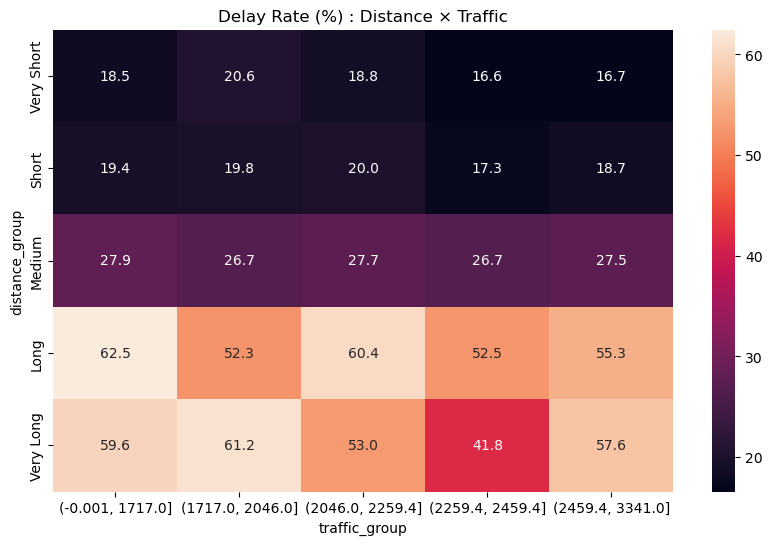

In [56]:
heatmap_data = pd.pivot_table(
    df,
    values="delay",
    index="distance_group",
    columns="traffic_group",
    aggfunc="mean"
) * 100

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f"
)

plt.title(
    "Delay Rate (%) : Distance × Traffic"
)

plt.show()

In [57]:
df["route_history_group"] = pd.qcut(
    df["route_delay_rate_hist"],
    5,
    duplicates="drop"
)

route_hist = (
    df.groupby(
        "route_history_group",
        observed=True
    )["delay"]
    .agg(
        Delay_Rate="mean",
        Shipments="count"
    )
)

route_hist["Delay_Rate"] *= 100

display(route_hist)

,Delay_Rate,Shipments
route_history_group,,
"(-0.001, 0.2]",33.939750,5112
"(0.2, 0.349]",26.251526,4095
"(0.349, 0.5]",39.910026,1556
"(0.5, 1.0]",55.857605,1545


In [58]:
df["truck_history_group"] = pd.qcut(
    df["truck_delay_rate_hist"],
    5,
    duplicates="drop"
)

truck_hist = (
    df.groupby(
        "truck_history_group",
        observed=True
    )["delay"]
    .agg(
        Delay_Rate="mean",
        Shipments="count"
    )
)

truck_hist["Delay_Rate"] *= 100

display(truck_hist)

,Delay_Rate,Shipments
truck_history_group,,
"(-0.001, 0.25]",33.871546,5574
"(0.25, 0.349]",28.876292,2999
"(0.349, 0.455]",36.356822,1334
"(0.455, 1.0]",43.940025,2401


In [59]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [60]:
import shap
import joblib
import json

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [61]:
from pathlib import Path

# Your notebook is inside:
# C:\Users\shriv\logistics\notebooks

ROOT = Path.cwd().parent

print("Current directory:", Path.cwd())
print("Project root:", ROOT)
print("Root exists:", ROOT.exists())

Current directory: c:\Users\shriv\logistics\notebooks
Project root: c:\Users\shriv\logistics
Root exists: True


In [62]:
MODEL_DIR = ROOT / "logistics-ai" / "models"

print("Model directory:", MODEL_DIR)
print("Exists:", MODEL_DIR.exists())

if MODEL_DIR.exists():
    for file in MODEL_DIR.iterdir():
        print(file.name)

Model directory: c:\Users\shriv\logistics\logistics-ai\models
Exists: True
delay_xgboost.pkl
feature_columns.json
preprocessor.pkl


In [63]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [64]:
model = joblib.load(
    MODEL_DIR / "delay_xgboost.pkl"
)

preprocessor = joblib.load(
    MODEL_DIR / "preprocessor.pkl"
)

with open(
    MODEL_DIR / "feature_columns.json",
    "r"
) as f:
    feature_config = json.load(f)

feature_columns = feature_config["feature_names"]

numeric_features_model = feature_config["numeric_features"]

categorical_features_model = feature_config["categorical_features"]

target_column = feature_config["target"]

print("Model loaded successfully")

print("\nTotal input features:",
      len(feature_columns))

print("Numerical features:",
      len(numeric_features_model))

print("Categorical features:",
      len(categorical_features_model))

print("\nFeatures:")
print(feature_columns)

Model loaded successfully

Total input features: 33
Numerical features: 30
Categorical features: 3

Features:
['hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'is_peak_hour', 'truck_age', 'load_capacity_pounds', 'mileage_mpg', 'driver_age', 'experience', 'driver_ratings', 'average_speed_mph', 'distance', 'average_hours', 'weather_temp', 'weather_wind_speed', 'weather_precip', 'weather_humidity', 'weather_visibility', 'weather_chanceofrain', 'weather_chanceoffog', 'weather_chanceofsnow', 'weather_chanceofthunder', 'traffic_vehicles', 'traffic_accident', 'truck_trip_count_hist', 'truck_delay_rate_hist', 'route_trip_count_hist', 'route_delay_rate_hist', 'fuel_type', 'driving_style', 'truck_age_category']


In [65]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
import joblib

# --------------------------------------------------
# 1. Find project root
# --------------------------------------------------

ROOT = Path.cwd().parent

print("Current directory:", Path.cwd())
print("Project root:", ROOT)


# --------------------------------------------------
# 2. Load the actual modeling dataset
# --------------------------------------------------

DATA_PATH = ROOT / "data" / "processed" / "master_modeling.csv"

print("\nDataset:", DATA_PATH)
print("Exists:", DATA_PATH.exists())

df = pd.read_csv(DATA_PATH)

df["departure_date"] = pd.to_datetime(
    df["departure_date"]
)

print("Dataset loaded:", df.shape)


# --------------------------------------------------
# 3. Load model configuration
# --------------------------------------------------

MODEL_DIR = ROOT / "logistics-ai" / "models"

with open(
    MODEL_DIR / "feature_columns.json",
    "r"
) as f:
    feature_config = json.load(f)

feature_columns = feature_config["feature_names"]

numeric_features_model = (
    feature_config["numeric_features"]
)

categorical_features_model = (
    feature_config["categorical_features"]
)

target_column = feature_config["target"]


# --------------------------------------------------
# 4. Load trained model
# --------------------------------------------------

model = joblib.load(
    MODEL_DIR / "delay_xgboost.pkl"
)

preprocessor = joblib.load(
    MODEL_DIR / "preprocessor.pkl"
)


# --------------------------------------------------
# 5. Verify everything
# --------------------------------------------------

print("\n========== SETUP COMPLETE ==========")

print("Dataset shape:", df.shape)

print(
    "Total model features:",
    len(feature_columns)
)

print(
    "Numerical features:",
    len(numeric_features_model)
)

print(
    "Categorical features:",
    len(categorical_features_model)
)

print(
    "Target:",
    target_column
)

print("\nModel:", type(model).__name__)
print("Preprocessor:", type(preprocessor).__name__)

Current directory: c:\Users\shriv\logistics\notebooks
Project root: c:\Users\shriv\logistics

Dataset: c:\Users\shriv\logistics\data\processed\master_modeling.csv
Exists: True
Dataset loaded: (12308, 38)

========== SETUP COMPLETE ==========
Dataset shape: (12308, 38)
Total model features: 33
Numerical features: 30
Categorical features: 3
Target: delay

Model: XGBClassifier
Preprocessor: ColumnTransformer


In [66]:
print("\nFirst 10 model features:")
print(feature_columns[:10])

print("\nDataset columns missing from model:")
print([
    col for col in feature_columns
    if col not in df.columns
])

print("\nTarget distribution:")
print(df["delay"].value_counts())


First 10 model features:
['hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'is_peak_hour', 'truck_age', 'load_capacity_pounds', 'mileage_mpg', 'driver_age']

Dataset columns missing from model:
[]

Target distribution:
delay
0    8014
1    4294
Name: count, dtype: int64


In [67]:
X = df[feature_columns].copy()
y = df["delay"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12308, 33)
y shape: (12308,)


In [68]:
df_sorted = df.sort_values("departure_date").reset_index(drop=True)

n = len(df_sorted)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df_sorted.iloc[:train_end]
val_df = df_sorted.iloc[train_end:val_end]
test_df = df_sorted.iloc[val_end:]

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nDate ranges:")

print(
    "Train:",
    train_df["departure_date"].min(),
    "→",
    train_df["departure_date"].max()
)

print(
    "Validation:",
    val_df["departure_date"].min(),
    "→",
    val_df["departure_date"].max()
)

print(
    "Test:",
    test_df["departure_date"].min(),
    "→",
    test_df["departure_date"].max()
)

Train:

 8615
Validation: 1846
Test: 1847

Date ranges:
Train: 2019-01-01 07:00:00 → 2019-01-31 07:00:00
Validation: 2019-01-31 07:00:00 → 2019-02-06 07:00:00
Test: 2019-02-06 07:00:00 → 2019-02-12 07:00:00


In [69]:
X_val = val_df[feature_columns]
y_val = val_df["delay"]

X_val_transformed = preprocessor.transform(X_val)

print("Original validation shape:", X_val.shape)
print("Transformed validation shape:", X_val_transformed.shape)

Original validation shape: (1846, 33)
Transformed validation shape: (1846, 33)


In [70]:
try:
    transformed_feature_names = (
        preprocessor.get_feature_names_out()
    )
except Exception:
    transformed_feature_names = feature_columns

print("Number of transformed features:",
      len(transformed_feature_names))

print(transformed_feature_names)

Number of transformed features: 33
['num__hour' 'num__day_of_week' 'num__day_of_month' 'num__month'
 'num__is_weekend' 'num__is_peak_hour' 'num__truck_age'
 'num__load_capacity_pounds' 'num__mileage_mpg' 'num__driver_age'
 'num__experience' 'num__driver_ratings' 'num__average_speed_mph'
 'num__distance' 'num__average_hours' 'num__weather_temp'
 'num__weather_wind_speed' 'num__weather_precip' 'num__weather_humidity'
 'num__weather_visibility' 'num__weather_chanceofrain'
 'num__weather_chanceoffog' 'num__weather_chanceofsnow'
 'num__weather_chanceofthunder' 'num__traffic_vehicles'
 'num__traffic_accident' 'num__truck_trip_count_hist'
 'num__truck_delay_rate_hist' 'num__route_trip_count_hist'
 'num__route_delay_rate_hist' 'cat__fuel_type' 'cat__driving_style'
 'cat__truck_age_category']


In [71]:
explainer = shap.TreeExplainer(model)

# Limit sample size so SHAP doesn't take unnecessarily long
sample_size = min(2000, X_val_transformed.shape[0])

rng = np.random.RandomState(42)

sample_indices = rng.choice(
    X_val_transformed.shape[0],
    size=sample_size,
    replace=False
)

X_shap = X_val_transformed[sample_indices]

print("SHAP sample size:", X_shap.shape[0])

SHAP sample size: 1846


In [72]:
shap_values = explainer.shap_values(X_shap)

print("SHAP shape:", np.array(shap_values).shape)

SHAP shape: (1846, 33)


In [73]:
print("plt:", plt is not None)
print("shap:", shap.__version__)
print("df:", df.shape)
print("model:", type(model).__name__)

plt: True
shap: 0.52.0
df: (12308, 38)
model: XGBClassifier


In [74]:
X_val = df.sort_values("departure_date").iloc[
    int(len(df) * 0.70):
    int(len(df) * 0.85)
][feature_columns]

X_val_transformed = preprocessor.transform(X_val)

print("Validation shape:", X_val.shape)
print("Transformed shape:", X_val_transformed.shape)

Validation shape: (1846, 33)
Transformed shape: (1846, 33)


In [75]:
try:
    transformed_feature_names = (
        preprocessor.get_feature_names_out()
    )
except Exception:
    transformed_feature_names = feature_columns

print(
    "Transformed features:",
    len(transformed_feature_names)
)

Transformed features: 33


In [76]:
explainer = shap.TreeExplainer(model)

sample_size = min(
    2000,
    X_val_transformed.shape[0]
)

rng = np.random.RandomState(42)

sample_indices = rng.choice(
    X_val_transformed.shape[0],
    size=sample_size,
    replace=False
)

X_shap = X_val_transformed[sample_indices]

shap_values = explainer.shap_values(X_shap)

print("SHAP calculated successfully")
print("SHAP shape:", np.array(shap_values).shape)

SHAP calculated successfully
SHAP shape: (1846, 33)


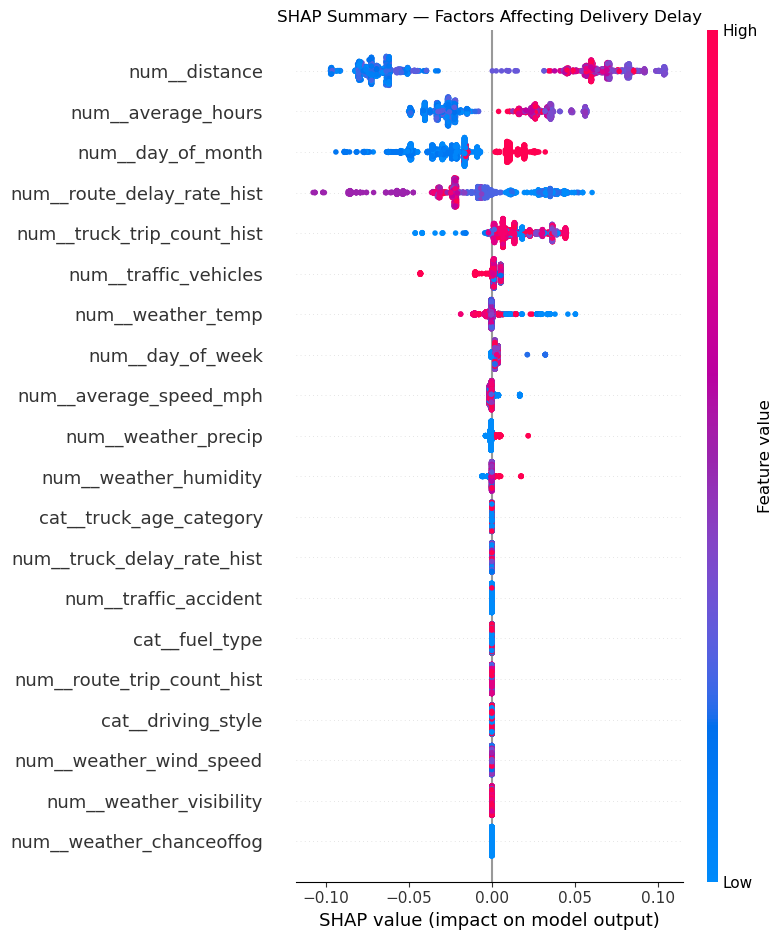

In [77]:
plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=transformed_feature_names,
    show=False
)

plt.title(
    "SHAP Summary — Factors Affecting Delivery Delay"
)

plt.tight_layout()
plt.show()

In [78]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": transformed_feature_names,
    "Mean_Absolute_SHAP": mean_abs_shap
})

shap_importance = shap_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

shap_importance["Importance_%"] = (
    shap_importance["Mean_Absolute_SHAP"]
    / shap_importance["Mean_Absolute_SHAP"].sum()
    * 100
)

display(shap_importance)

,Feature,Mean_Absolute_SHAP,Importance_%
0,num__distance,0.069174,39.178841
1,num__average_hours,0.030906,17.504320
2,num__day_of_month,0.024950,14.130859
3,num__route_delay_rate_hist,0.023822,13.492311
4,num__truck_trip_count_hist,0.016350,9.260421
5,num__traffic_vehicles,0.003488,1.975427
6,num__weather_temp,0.003175,1.798285
7,num__day_of_week,0.002543,1.440429
8,num__average_speed_mph,0.000957,0.542229
9,num__weather_precip,0.000801,0.453559


In [79]:
def shap_feature_name(feature):
    matches = [
        name for name in transformed_feature_names
        if name.endswith("__" + feature)
        or name == feature
    ]

    if not matches:
        raise ValueError(
            f"Could not find transformed feature for: {feature}"
        )

    return matches[0]


print(shap_feature_name("distance"))
print(shap_feature_name("average_hours"))
print(shap_feature_name("traffic_vehicles"))

num__distance
num__average_hours
num__traffic_vehicles


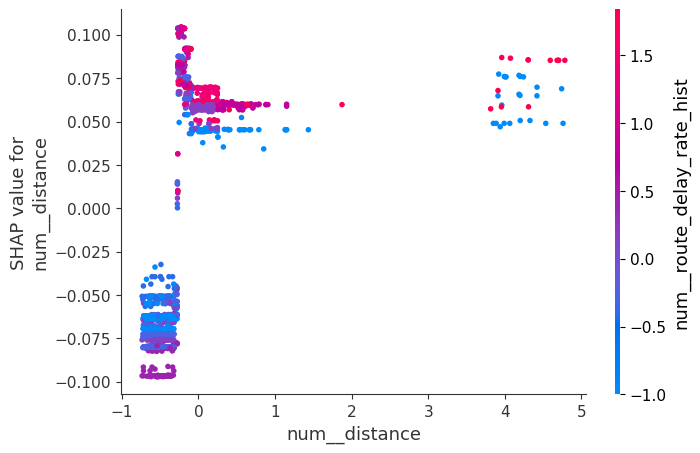

In [80]:
shap.dependence_plot(
    shap_feature_name("distance"),
    shap_values,
    X_shap,
    feature_names=transformed_feature_names
)

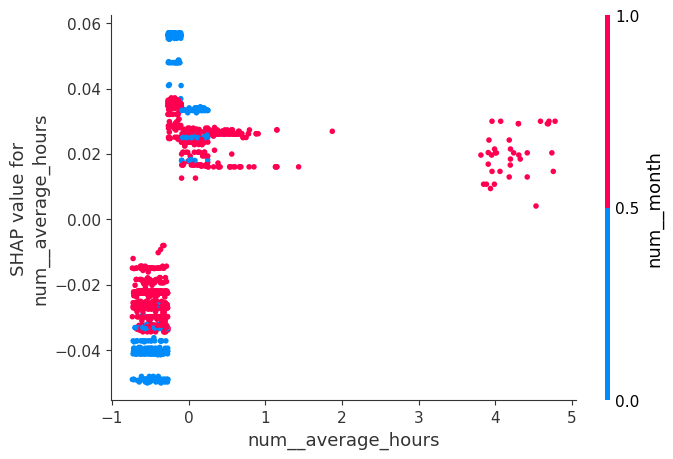

In [81]:
shap.dependence_plot(
    "num__average_hours",
    shap_values,
    X_shap,
    feature_names=transformed_feature_names
)

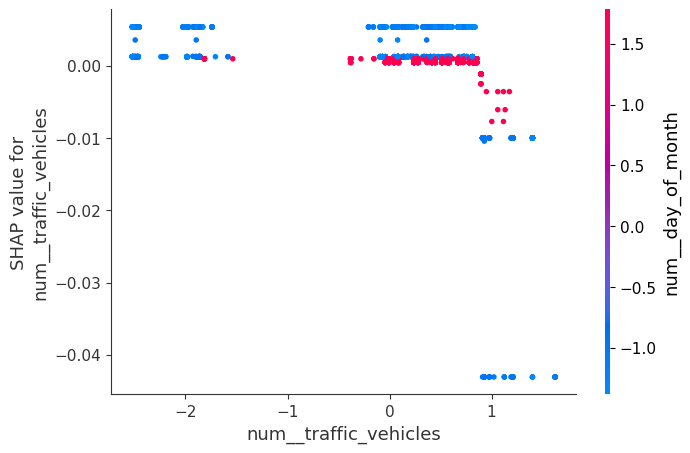

In [82]:
shap.dependence_plot(
    "num__traffic_vehicles",
    shap_values,
    X_shap,
    feature_names=transformed_feature_names
)

In [83]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

X_test = test_df[feature_columns]
y_test = test_df["delay"]

X_test_transformed = preprocessor.transform(X_test)

test_probability = model.predict_proba(
    X_test_transformed
)[:, 1]

test_prediction = (
    test_probability >= 0.5
).astype(int)

baseline_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        test_prediction
    ),

    "Precision": precision_score(
        y_test,
        test_prediction,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        test_prediction,
        zero_division=0
    ),

    "F1": f1_score(
        y_test,
        test_prediction,
        zero_division=0
    ),

    "ROC_AUC": roc_auc_score(
        y_test,
        test_probability
    ),

    "PR_AUC": average_precision_score(
        y_test,
        test_probability
    )
}

baseline_metrics

{'Accuracy': 0.7596101786681104,
 'Precision': 0.713855421686747,
 'Recall': 0.6510989010989011,
 'F1': 0.6810344827586207,
 'ROC_AUC': np.float64(0.8114516738846498),
 'PR_AUC': np.float64(0.6588502505515776)}

In [84]:
feature_groups = {

    "Time": [
        "hour",
        "day_of_week",
        "day_of_month",
        "month",
        "is_weekend",
        "is_peak_hour"
    ],

    "Truck": [
        "truck_age",
        "load_capacity_pounds",
        "mileage_mpg",
        "fuel_type",
        "truck_age_category"
    ],

    "Driver": [
        "driver_age",
        "experience",
        "driving_style",
        "driver_ratings",
        "average_speed_mph"
    ],

    "Route": [
        "distance",
        "average_hours"
    ],

    "Weather": [
        "weather_temp",
        "weather_wind_speed",
        "weather_precip",
        "weather_humidity",
        "weather_visibility",
        "weather_chanceofrain",
        "weather_chanceoffog",
        "weather_chanceofsnow",
        "weather_chanceofthunder"
    ],

    "Traffic": [
        "traffic_vehicles",
        "traffic_accident"
    ],

    "Historical": [
        "truck_trip_count_hist",
        "truck_delay_rate_hist",
        "route_trip_count_hist",
        "route_delay_rate_hist"
    ]
}

# Keep only columns actually present
for group in feature_groups:
    feature_groups[group] = [
        f for f in feature_groups[group]
        if f in feature_columns
    ]

feature_groups

{'Time': ['hour',
  'day_of_week',
  'day_of_month',
  'month',
  'is_weekend',
  'is_peak_hour'],
 'Truck': ['truck_age',
  'load_capacity_pounds',
  'mileage_mpg',
  'fuel_type',
  'truck_age_category'],
 'Driver': ['driver_age',
  'experience',
  'driving_style',
  'driver_ratings',
  'average_speed_mph'],
 'Route': ['distance', 'average_hours'],
 'Weather': ['weather_temp',
  'weather_wind_speed',
  'weather_precip',
  'weather_humidity',
  'weather_visibility',
  'weather_chanceofrain',
  'weather_chanceoffog',
  'weather_chanceofsnow',
  'weather_chanceofthunder'],
 'Traffic': ['traffic_vehicles', 'traffic_accident'],
 'Historical': ['truck_trip_count_hist',
  'truck_delay_rate_hist',
  'route_trip_count_hist',
  'route_delay_rate_hist']}

In [85]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)

In [86]:
df_sorted = df.sort_values(
    "departure_date"
).reset_index(drop=True)

n = len(df_sorted)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df_sorted.iloc[:train_end]
val_df = df_sorted.iloc[train_end:val_end]
test_df = df_sorted.iloc[val_end:]

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (8615, 38)
Validation: (1846, 38)
Test: (1847, 38)


In [97]:
def run_ablation(
    features_to_use,
    experiment_name
):

    # -----------------------------------------
    # Select numerical and categorical features
    # -----------------------------------------

    numeric_cols = [
        f for f in numeric_features_model
        if f in features_to_use
    ]

    categorical_cols = [
        f for f in categorical_features_model
        if f in features_to_use
    ]

    # -----------------------------------------
    # Split X / y
    # -----------------------------------------

    X_train = train_df[features_to_use].copy()
    y_train = train_df["delay"].copy()

    X_val = val_df[features_to_use].copy()
    y_val = val_df["delay"].copy()

    X_test = test_df[features_to_use].copy()
    y_test = test_df["delay"].copy()

    # -----------------------------------------
    # Preprocessing
    # Same structure as original project
    # -----------------------------------------

    transformers = []

    if numeric_cols:
        numeric_pipeline = Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "scaler",
                StandardScaler()
            )
        ])

        transformers.append(
            (
                "num",
                numeric_pipeline,
                numeric_cols
            )
        )

    if categorical_cols:
        categorical_pipeline = Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="constant",
                    fill_value="Unknown"
                )
            ),
            (
                "encoder",
                OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1
                )
            )
        ])

        transformers.append(
            (
                "cat",
                categorical_pipeline,
                categorical_cols
            )
        )

    preprocessor_ablation = ColumnTransformer(
        transformers=transformers
    )

    # -----------------------------------------
    # Fit preprocessing ONLY on train
    # -----------------------------------------

    X_train_t = preprocessor_ablation.fit_transform(
        X_train
    )

    X_val_t = preprocessor_ablation.transform(
        X_val
    )

    X_test_t = preprocessor_ablation.transform(
        X_test
    )

    # -----------------------------------------
    # EXACT ORIGINAL XGBOOST PARAMETERS
    # -----------------------------------------

    model_ablation = XGBClassifier(
        objective="binary:logistic",

        n_estimators=300,
        learning_rate=0.05,

        max_depth=4,
        min_child_weight=10,

        subsample=0.8,
        colsample_bytree=0.8,

        reg_alpha=0.1,
        reg_lambda=1.0,

        scale_pos_weight=2.0006966213862767,

        eval_metric="auc",

        early_stopping_rounds=30,

        random_state=42,
        n_jobs=-1
    )

    # -----------------------------------------
    # Train
    # -----------------------------------------

    model_ablation.fit(
        X_train_t,
        y_train,

        eval_set=[
            (X_val_t, y_val)
        ],

        verbose=False
    )

    # -----------------------------------------
    # Test predictions
    # -----------------------------------------

    probability = model_ablation.predict_proba(
        X_test_t
    )[:, 1]

    prediction = (
        probability >= 0.5
    ).astype(int)

    # -----------------------------------------
    # Metrics
    # -----------------------------------------

    return {
        "Experiment": experiment_name,

        "Features": len(features_to_use),

        "Accuracy": accuracy_score(
            y_test,
            prediction
        ),

        "Precision": precision_score(
            y_test,
            prediction,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            prediction,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            prediction,
            zero_division=0
        ),

        "ROC_AUC": roc_auc_score(
            y_test,
            probability
        ),

        "PR_AUC": average_precision_score(
            y_test,
            probability
        )
    }

In [98]:
baseline_ablation = run_ablation(
    feature_columns,
    "All 33 features"
)

print(baseline_ablation)

{'Experiment': 'All 33 features', 'Features': 33, 'Accuracy': 0.7531131564699513, 'Precision': 0.7105263157894737, 'Recall': 0.6304945054945055, 'F1': 0.6681222707423581, 'ROC_AUC': np.float64(0.8085067858861424), 'PR_AUC': np.float64(0.6611303669463241)}


In [89]:
zero_shap_features = [
    "hour",
    "truck_age",
    "mileage_mpg",
    "load_capacity_pounds",
    "month",
    "is_weekend",
    "weather_wind_speed",
    "driver_age",
    "experience",
    "driver_ratings",
    "is_peak_hour",
    "weather_chanceoffog",
    "weather_chanceofrain",
    "weather_visibility",
    "weather_chanceofthunder",
    "weather_chanceofsnow",
    "truck_delay_rate_hist",
    "traffic_accident",
    "route_trip_count_hist",
    "fuel_type",
    "driving_style",
    "truck_age_category"
]

zero_shap_features = [
    f for f in zero_shap_features
    if f in feature_columns
]

reduced_features = [
    f for f in feature_columns
    if f not in zero_shap_features
]

print("Original:", len(feature_columns))
print("Removed:", len(zero_shap_features))
print("Remaining:", len(reduced_features))

print("\nRemaining features:")
print(reduced_features)

Original: 33
Removed: 22
Remaining: 11

Remaining features:
['day_of_week', 'day_of_month', 'average_speed_mph', 'distance', 'average_hours', 'weather_temp', 'weather_precip', 'weather_humidity', 'traffic_vehicles', 'truck_trip_count_hist', 'route_delay_rate_hist']


In [90]:
zero_removed_result = run_ablation(
    reduced_features,
    "Remove zero-SHAP features"
)

print(zero_removed_result)

{'Experiment': 'Remove zero-SHAP features', 'Features': 11, 'Accuracy': 0.6783974011911207, 'Precision': 0.6040372670807453, 'Recall': 0.5343406593406593, 'F1': 0.5670553935860059, 'ROC_AUC': np.float64(0.7180542870891395), 'PR_AUC': np.float64(0.5894184274788092)}


In [91]:
baseline_ablation = run_ablation(
    feature_columns,
    "All 33 features"
)

print(baseline_ablation)

{'Experiment': 'All 33 features', 'Features': 33, 'Accuracy': 0.6773145641580942, 'Precision': 0.6134020618556701, 'Recall': 0.49038461538461536, 'F1': 0.5450381679389313, 'ROC_AUC': np.float64(0.7116894499602274), 'PR_AUC': np.float64(0.5888177403911445)}


In [92]:
loo_results = []

for feature in feature_columns:

    features_without = [
        f for f in feature_columns
        if f != feature
    ]

    result = run_ablation(
        features_without,
        f"Remove {feature}"
    )

    result["Removed_Feature"] = feature

    loo_results.append(result)

    print(
        f"Finished: {feature} | "
        f"ROC-AUC = {result['ROC_AUC']:.4f}"
    )

Finished: hour | ROC-AUC = 0.7210
Finished: day_of_week | ROC-AUC = 0.7278
Finished: day_of_month | ROC-AUC = 0.7607
Finished: month | ROC-AUC = 0.7249
Finished: is_weekend | ROC-AUC = 0.7269
Finished: is_peak_hour | ROC-AUC = 0.7411
Finished: truck_age | ROC-AUC = 0.7114
Finished: load_capacity_pounds | ROC-AUC = 0.7244
Finished: mileage_mpg | ROC-AUC = 0.7295
Finished: driver_age | ROC-AUC = 0.7206
Finished: experience | ROC-AUC = 0.7195
Finished: driver_ratings | ROC-AUC = 0.7233
Finished: average_speed_mph | ROC-AUC = 0.7176
Finished: distance | ROC-AUC = 0.7255
Finished: average_hours | ROC-AUC = 0.7288
Finished: weather_temp | ROC-AUC = 0.7212
Finished: weather_wind_speed | ROC-AUC = 0.7078
Finished: weather_precip | ROC-AUC = 0.7147
Finished: weather_humidity | ROC-AUC = 0.7146
Finished: weather_visibility | ROC-AUC = 0.7275
Finished: weather_chanceofrain | ROC-AUC = 0.7290
Finished: weather_chanceoffog | ROC-AUC = 0.7290
Finished: weather_chanceofsnow | ROC-AUC = 0.7290
Finishe

In [93]:
loo_df = pd.DataFrame(loo_results)

baseline_auc = baseline_ablation["ROC_AUC"]
baseline_f1 = baseline_ablation["F1"]

loo_df["ROC_AUC_Change"] = (
    loo_df["ROC_AUC"] - baseline_auc
)

loo_df["F1_Change"] = (
    loo_df["F1"] - baseline_f1
)

loo_df = loo_df.sort_values(
    "ROC_AUC_Change"
)

display(
    loo_df[
        [
            "Removed_Feature",
            "Features",
            "ROC_AUC",
            "ROC_AUC_Change",
            "F1",
            "F1_Change",
            "PR_AUC"
        ]
    ]
)

,Removed_Feature,Features,ROC_AUC,ROC_AUC_Change,F1,F1_Change,PR_AUC
29,route_delay_rate_hist,32,0.695589,-0.016101,0.523967,-0.021071,0.579518
16,weather_wind_speed,32,0.707755,-0.003934,0.535012,-0.010026,0.579018
31,driving_style,32,0.710846,-0.000843,0.533333,-0.011705,0.587174
6,truck_age,32,0.711395,-0.000295,0.518936,-0.026102,0.584668
18,weather_humidity,32,0.714588,0.002898,0.535800,-0.009238,0.596750
17,weather_precip,32,0.714686,0.002996,0.535630,-0.009408,0.590032
12,average_speed_mph,32,0.717616,0.005927,0.533438,-0.011600,0.590376
30,fuel_type,32,0.718501,0.006812,0.556068,0.011029,0.591896
10,experience,32,0.719466,0.007777,0.522436,-0.022602,0.594287
25,traffic_accident,32,0.719610,0.007920,0.554254,0.009216,0.592828


In [95]:
print("Model parameters:")
print(model.get_params())

Model parameters:
{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': 30, 'enable_categorical': False, 'eval_metric': 'auc', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 4, 'max_leaves': None, 'min_child_weight': 10, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 300, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'sampling_method': None, 'scale_pos_weight': np.float64(2.0006966213862767), 'subsample': 0.8, 'tree_method': None, 'validate_parameters': None, 'verbosity': 0}


In [96]:
print("XGBoost parameters:")
print(model.get_xgb_params())

XGBoost parameters:
{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'eval_metric': 'auc', 'gamma': None, 'grow_policy': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 4, 'max_leaves': None, 'min_child_weight': 10, 'monotone_constraints': None, 'multi_strategy': None, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'sampling_method': None, 'scale_pos_weight': np.float64(2.0006966213862767), 'subsample': 0.8, 'tree_method': None, 'validate_parameters': None, 'verbosity': 0}


In [99]:
baseline_auc = baseline_ablation["ROC_AUC"]
baseline_f1 = baseline_ablation["F1"]

print("Ablation baseline ROC-AUC:",
      baseline_auc)

print("Ablation baseline F1:",
      baseline_f1)

Ablation baseline ROC-AUC: 0.8085067858861424
Ablation baseline F1: 0.6681222707423581


In [100]:
loo_results = []

for feature in feature_columns:

    features_without = [
        f for f in feature_columns
        if f != feature
    ]

    result = run_ablation(
        features_without,
        f"Remove {feature}"
    )

    result["Removed_Feature"] = feature

    loo_results.append(result)

    print(
        f"Finished: {feature:30s} "
        f"ROC-AUC = {result['ROC_AUC']:.4f}"
    )

Finished: hour                           ROC-AUC = 0.8032
Finished: day_of_week                    ROC-AUC = 0.8079
Finished: day_of_month                   ROC-AUC = 0.8189
Finished: month                          ROC-AUC = 0.8030
Finished: is_weekend                     ROC-AUC = 0.8050
Finished: is_peak_hour                   ROC-AUC = 0.8046
Finished: truck_age                      ROC-AUC = 0.8038
Finished: load_capacity_pounds           ROC-AUC = 0.8028
Finished: mileage_mpg                    ROC-AUC = 0.7998
Finished: driver_age                     ROC-AUC = 0.8105
Finished: experience                     ROC-AUC = 0.8074
Finished: driver_ratings                 ROC-AUC = 0.8049
Finished: average_speed_mph              ROC-AUC = 0.8046
Finished: distance                       ROC-AUC = 0.8098
Finished: average_hours                  ROC-AUC = 0.8098
Finished: weather_temp                   ROC-AUC = 0.8121
Finished: weather_wind_speed             ROC-AUC = 0.8044
Finished: weat

In [101]:
loo_df = pd.DataFrame(loo_results)

loo_df["ROC_AUC_Change"] = (
    loo_df["ROC_AUC"] -
    baseline_auc
)

loo_df["F1_Change"] = (
    loo_df["F1"] -
    baseline_f1
)

loo_df = loo_df.sort_values(
    "ROC_AUC_Change"
)

display(
    loo_df[
        [
            "Removed_Feature",
            "Features",
            "ROC_AUC",
            "ROC_AUC_Change",
            "F1",
            "F1_Change",
            "PR_AUC"
        ]
    ]
)

,Removed_Feature,Features,ROC_AUC,ROC_AUC_Change,F1,F1_Change,PR_AUC
29,route_delay_rate_hist,32,0.768716,-0.039791,0.691412,0.023290,0.637735
8,mileage_mpg,32,0.799816,-0.008690,0.652461,-0.015661,0.654793
7,load_capacity_pounds,32,0.802813,-0.005694,0.645306,-0.022817,0.653098
3,month,32,0.802959,-0.005547,0.638266,-0.029856,0.653656
0,hour,32,0.803225,-0.005282,0.641791,-0.026331,0.655926
6,truck_age,32,0.803779,-0.004728,0.648368,-0.019754,0.654281
16,weather_wind_speed,32,0.804431,-0.004076,0.646177,-0.021945,0.649888
12,average_speed_mph,32,0.804553,-0.003954,0.654919,-0.013203,0.657864
5,is_peak_hour,32,0.804634,-0.003872,0.646360,-0.021763,0.654215
11,driver_ratings,32,0.804856,-0.003651,0.653451,-0.014671,0.657764


In [102]:
candidate_remove = [
    "day_of_month",
    "truck_trip_count_hist",
    "traffic_vehicles"
]

In [103]:
candidate_features = [
    f for f in feature_columns
    if f not in candidate_remove
]

candidate_result = run_ablation(
    candidate_features,
    "Remove top 3 removal candidates"
)

print(candidate_result)

{'Experiment': 'Remove top 3 removal candidates', 'Features': 30, 'Accuracy': 0.7693557119653492, 'Precision': 0.6955958549222798, 'Recall': 0.7376373626373627, 'F1': 0.716, 'ROC_AUC': np.float64(0.8188537891956122), 'PR_AUC': np.float64(0.6874295866805106)}


In [104]:
print("Baseline ROC-AUC:",
      baseline_ablation["ROC_AUC"])

print("Reduced ROC-AUC:",
      candidate_result["ROC_AUC"])

print(
    "Change:",
    candidate_result["ROC_AUC"]
    - baseline_ablation["ROC_AUC"]
)

Baseline ROC-AUC: 0.8085067858861424
Reduced ROC-AUC: 0.8188537891956122
Change: 0.010347003309469804


In [105]:
next_remove = [
    "weather_temp",
    "route_trip_count_hist",
    "truck_delay_rate_hist",
    "traffic_accident"
]

candidate_features_2 = [
    f for f in candidate_features
    if f not in next_remove
]

result_2 = run_ablation(
    candidate_features_2,
    "Remove 7 candidate features"
)

print(result_2)

print("\nPrevious reduced ROC-AUC:",
      candidate_result["ROC_AUC"])

print("New ROC-AUC:",
      result_2["ROC_AUC"])

print(
    "Change:",
    result_2["ROC_AUC"]
    - candidate_result["ROC_AUC"]
)

{'Experiment': 'Remove 7 candidate features', 'Features': 26, 'Accuracy': 0.7866811044937737, 'Precision': 0.7281420765027322, 'Recall': 0.7321428571428571, 'F1': 0.7301369863013699, 'ROC_AUC': np.float64(0.820800066778619), 'PR_AUC': np.float64(0.6876096077315381)}

Previous reduced ROC-AUC: 0.8188537891956122
New ROC-AUC: 0.820800066778619
Change: 0.0019462775830068058
